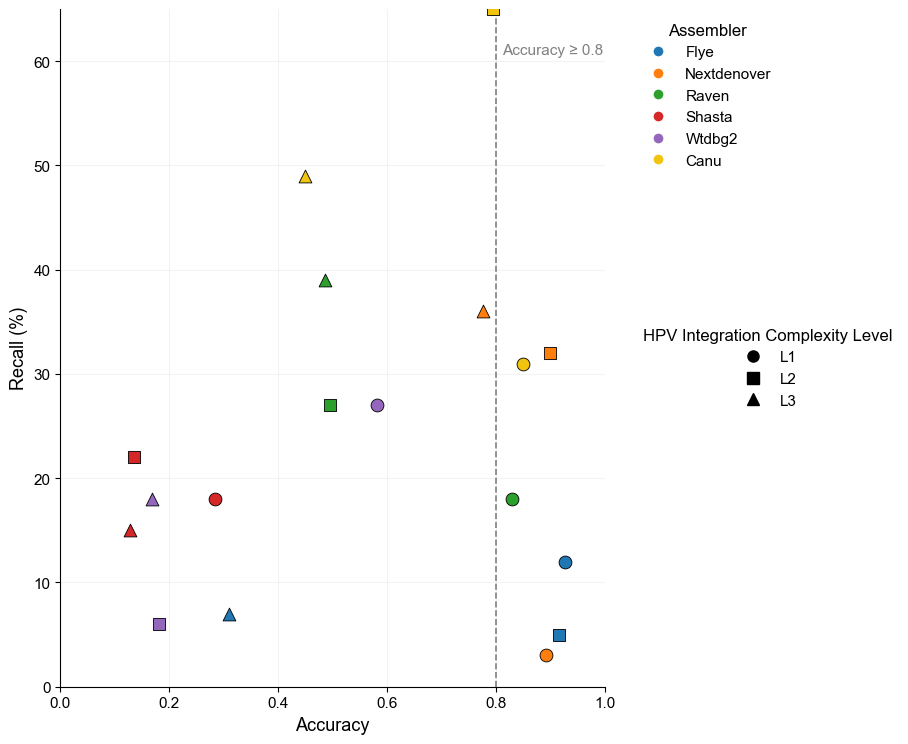

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

####### v2

# --- Font settings ---
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# load data
df = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/Accurcy_recall_plot.csv")

df[["tool","level"]] = df["ID"].str.split("_", expand=True)
df["level"] = pd.Categorical(
    df["level"],
    categories=["l1","l2","l3"],
    ordered=True
)

# fixed tool order and colors, matching previous figure
tool_order = [
    "Flye",
    "Nextdenover",
    "Raven",
    "Shasta",
    "Wtdbg2",
    "Canu",
]

tool_colors = {
    "Flye": "#1f77b4",         # tab10 blue
    "Nextdenover": "#ff7f0e",  # tab10 orange
    "Raven": "#2ca02c",        # tab10 green
    "Shasta": "#d62728",       # tab10 red
    "Wtdbg2": "#9467bd",       # tab10 purple
    "Canu": "#f1c40f",         # yellow
}

# preserve fixed order, only include tools present in the csv
tools = [t for t in tool_order if t in df["tool"].unique()]

# keep any unexpected tools instead of dropping them
extra_tools = [t for t in df["tool"].unique() if t not in tools]
tools = tools + extra_tools

colors = {
    t: tool_colors.get(t, "#7f7f7f")
    for t in tools
}

marker_map = {
    "l1": "o",
    "l2": "s",
    "l3": "^"
}

# --- Figure layout: increased height ---
fig = plt.figure(figsize=(10.5, 8.8))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 0.45],
    wspace=0.06
)

ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])

ax_leg.axis("off")

# --- Background gray points ---
for lv, mk in marker_map.items():

    sub = df[df["level"] == lv]

    ax.scatter(
        sub["Accuracy"],
        sub["Recall"],
        color="lightgray",
        marker=mk,
        s=95,
        edgecolor="white",
        linewidth=0.6,
        zorder=1
    )

# --- Colored points ---
for tool, sub in df.groupby("tool"):

    for _, row in sub.iterrows():

        ax.scatter(
            row["Accuracy"],
            row["Recall"],
            color=colors[tool],
            marker=marker_map[row["level"]],
            s=85,
            edgecolor="black",
            linewidth=0.6,
            zorder=3
        )

# --- Accuracy threshold line ---
thr = 0.8

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.2,
    color="gray",
    zorder=2
)

ax.text(
    thr + 0.01,
    df["Recall"].max() * 0.95,
    "Accuracy ≥ 0.8",
    color="gray",
    fontsize=11,
    va="top"
)

# --- Axis limits ---
ax.set_xlim(0, 1.0)

ymax = max(
    65,
    int(np.ceil(df["Recall"].max() / 5) * 5)
)

ax.set_ylim(0, ymax)

# --- Labels ---
ax.set_xlabel("Accuracy", fontsize=13)
ax.set_ylabel("Recall (%)", fontsize=13)

# --- Ticks ---
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, ymax + 1, 10))

ax.tick_params(axis='both', labelsize=11)

# --- Grid + remove top/right borders ---
ax.grid(alpha=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Legends ---
tool_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=tool,
        markerfacecolor=colors[tool],
        markersize=8
    )
    for tool in tools
]

level_handles = [
    Line2D(
        [0], [0],
        marker=marker_map[l],
        color='black',
        linestyle='None',
        label=l.upper(),
        markersize=8
    )
    for l in ["l1","l2","l3"]
]

leg1 = ax_leg.legend(
    handles=tool_handles,
    title="Assembler",
    loc="upper left",
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

ax_leg.add_artist(leg1)

ax_leg.legend(
    handles=level_handles,
    title="HPV Integration Complexity Level",
    loc="upper left",
    bbox_to_anchor=(0, 0.55),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# --- Save figures ---
fig.savefig(
    "Accuracy_Recall_main2.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "Accuracy_Recall_main2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

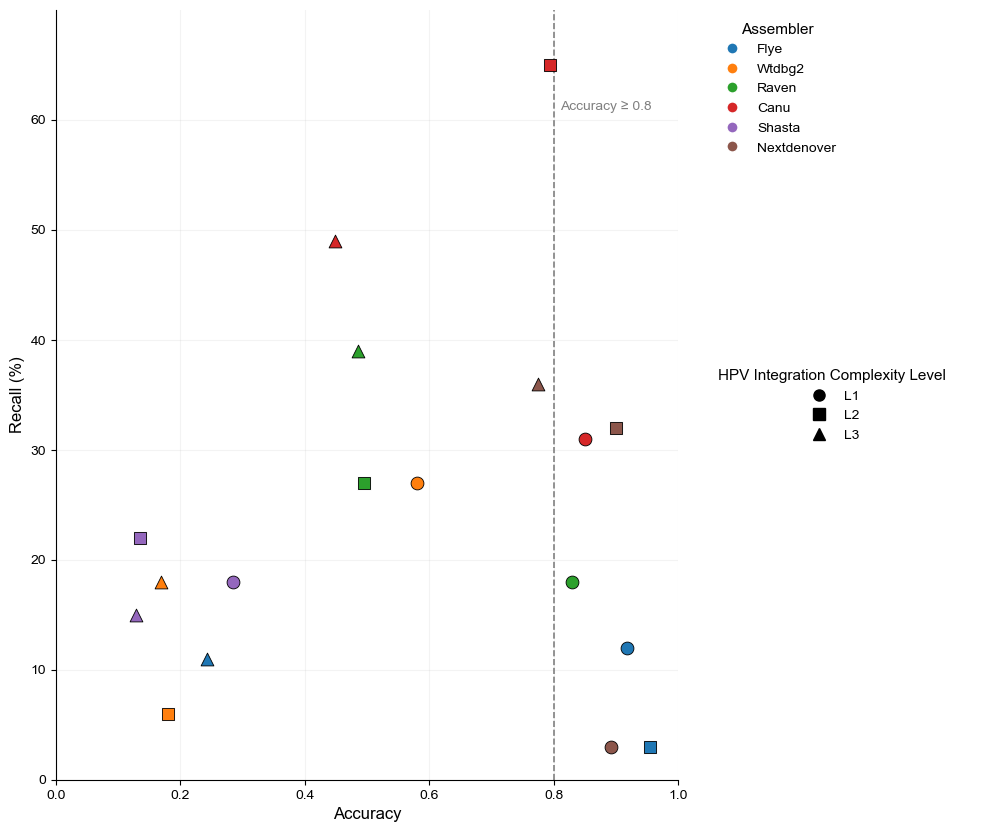

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
#######v2

# load data
df = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/Accurcy_recall_plot.csv")
df[["tool","level"]] = df["ID"].str.split("_", expand=True)
df["level"] = pd.Categorical(df["level"], categories=["l1","l2","l3"], ordered=True)

tools = list(df["tool"].unique())
colors = dict(zip(tools, plt.cm.tab10.colors[:len(tools)]))
marker_map = {"l1": "o", "l2": "s", "l3": "^"}

# --- Figure layout: main panel + legend panel ---
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.45], wspace=0.06)
ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis("off")


for lv, mk in marker_map.items():
    sub = df[df["level"] == lv]
    ax.scatter(sub["Accuracy"], sub["Recall"],
               color="lightgray", marker=mk, s=95,
               edgecolor="white", linewidth=0.6, zorder=1)


for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(row["Accuracy"], row["Recall"],
                   color=colors[tool],
                   marker=marker_map[row["level"]],
                   s=85,
                   edgecolor="black", linewidth=0.6,
                   zorder=3)


thr = 0.8
ax.axvline(thr, linestyle="--", linewidth=1.2, color="gray", zorder=2)
ax.text(thr + 0.01,
        df["Recall"].max() * 0.95,
        "Accuracy ≥ 0.8",
        color="gray",
        fontsize=10,
        va="top")

ax.set_xlim(0, 1.0)
ymax = max(65, int(np.ceil(df["Recall"].max() / 5) * 5))
ax.set_ylim(0, ymax+5)

ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("Recall (%)", fontsize=12)

ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, ymax + 1, 10))

# --- 轻微网格 + 去掉上右边框 ---
ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Legends in side panel ---
tool_handles = [
    Line2D([0],[0], marker='o', color='w', label=tool,
           markerfacecolor=colors[tool], markersize=8)
    for tool in tools
]
level_handles = [
    Line2D([0],[0], marker=marker_map[l], color='black',
           linestyle='None', label=l.upper(), markersize=8)
    for l in ["l1","l2","l3"]
]

leg1 = ax_leg.legend(handles=tool_handles, title="Assembler",
                     loc="upper left", frameon=False,
                     fontsize=10, title_fontsize=11)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=level_handles, title="HPV Integration Complexity Level",
              loc="upper left", bbox_to_anchor=(0, 0.55),
              frameon=False, fontsize=10, title_fontsize=11)


fig.savefig("Accuracy_Recall_main2.pdf")             
fig.savefig("Accuracy_Recall_main2.png", dpi=600)    

plt.show()

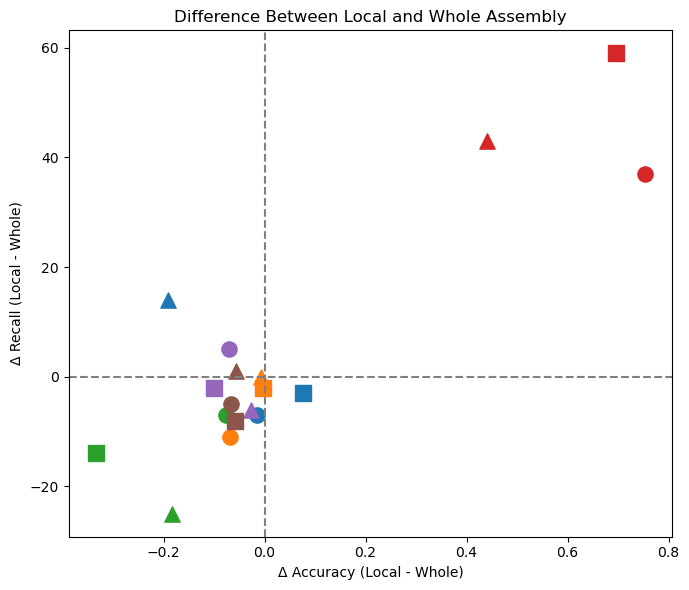

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


whole = pd.read_csv("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Accurcy_recall_plot.csv")
local = pd.read_csv("/Users/ppxinyi/Documents/Assembly_review/Local_result_30x/Accurcy_recall_plot.csv")

# merge
df = whole.merge(local, on="ID", suffixes=("_whole", "_local"))

# compute differences
df["dAccuracy"] = df["Accuracy_local"] - df["Accuracy_whole"]
df["dRecall"] = df["Recall_local"] - df["Recall_whole"]

# parse tool and level
df["Assembler"] = df["ID"].str.split("_").str[0]
df["Level"] = df["ID"].str.split("_").str[1].str.upper()

# color map
color_map = {
    "Flye":"tab:blue",
    "Wtdbg2":"tab:orange",
    "Raven":"tab:green",
    "Canu":"tab:red",
    "Shasta":"tab:purple",
    "Nextdenover":"tab:brown"
}

# marker map
marker_map = {
    "L1":"o",
    "L2":"s",
    "L3":"^"
}

plt.figure(figsize=(7,6))

for _,row in df.iterrows():
    plt.scatter(
        row["dAccuracy"],
        row["dRecall"],
        color=color_map[row["Assembler"]],
        marker=marker_map[row["Level"]],
        s=120
    )

plt.axhline(0, linestyle="--", color="grey")
plt.axvline(0, linestyle="--", color="grey")

plt.xlabel("Δ Accuracy (Local - Whole)")
plt.ylabel("Δ Recall (Local - Whole)")
plt.title("Difference Between Local and Whole Assembly")

plt.tight_layout()
plt.show()

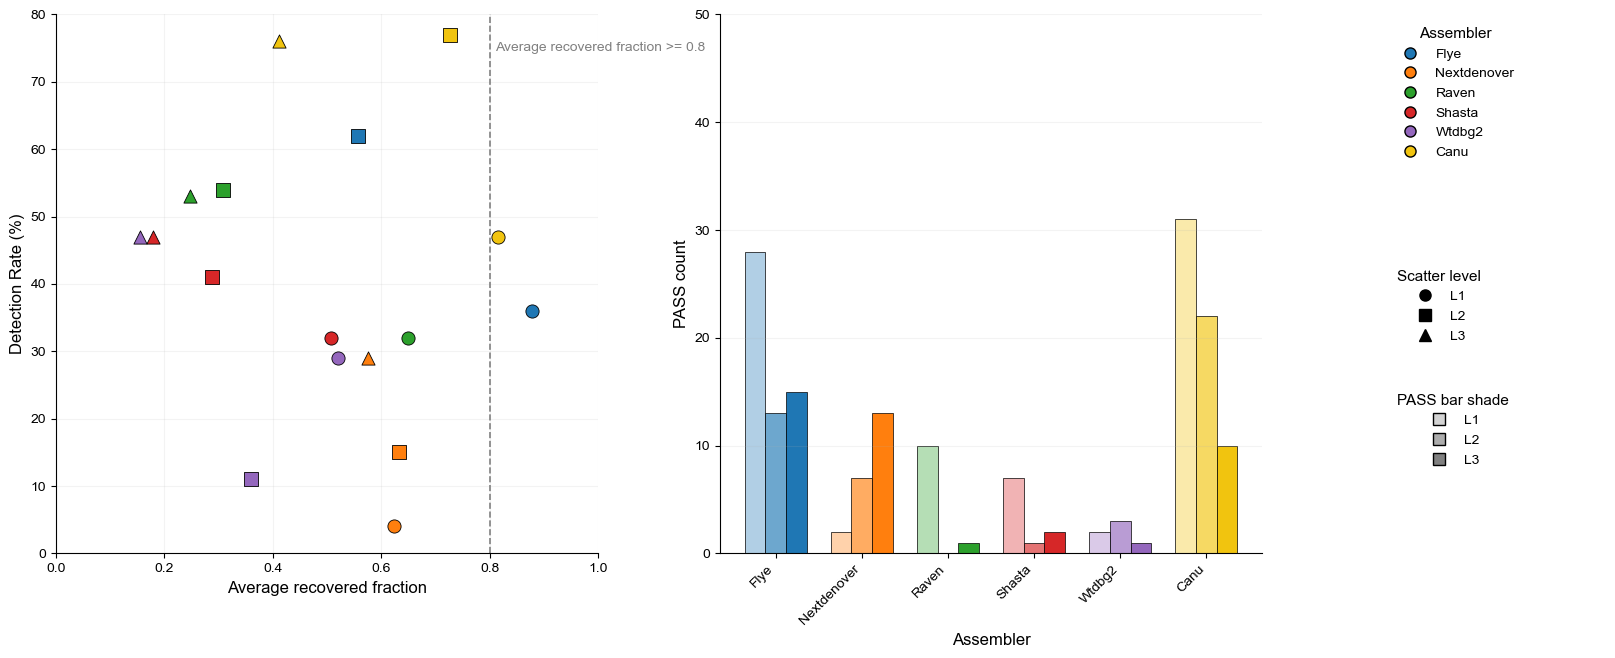

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np

# use Arial font
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# load new summary csv
df = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/local_summary.csv")

# split Tool into assembler + level
df[["tool", "level"]] = df["Tool"].str.rsplit("_", n=1, expand=True)
df["level"] = df["level"].str.lower()
df["level"] = pd.Categorical(df["level"], categories=["l1", "l2", "l3"], ordered=True)

# keep consistent order
df = df.sort_values(["tool", "level"])

# fixed tool order and colors, matching previous figure
tool_order = [
    "Flye",
    "Nextdenover",
    "Raven",
    "Shasta",
    "Wtdbg2",
    "Canu",
]

tool_colors = {
    "Flye": "#1f77b4",         # tab10 blue
    "Nextdenover": "#ff7f0e",  # tab10 orange
    "Raven": "#2ca02c",        # tab10 green
    "Shasta": "#d62728",       # tab10 red
    "Wtdbg2": "#9467bd",       # tab10 purple
    "Canu": "#f1c40f",         # yellow
}

# preserve fixed order, only include tools present in the csv
tools = [t for t in tool_order if t in df["tool"].unique()]

# keep any unexpected tools instead of dropping them
extra_tools = [t for t in df["tool"].unique() if t not in tools]
tools = tools + extra_tools

colors = {
    t: tool_colors.get(t, "#7f7f7f")
    for t in tools
}

marker_map = {"l1": "o", "l2": "s", "l3": "^"}

def lighten_color(color, amount=0.5):
    """
    amount: 0 = original color, 1 = white
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * amount)

level_lighten = {
    "l1": 0.65,  # lightest
    "l2": 0.35,  # medium
    "l3": 0.00,  # original / darkest
}

# figure: scatter + pass bar plot + legend
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 0.45], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[0, 2])
ax_leg.axis("off")

# -------------------------
# Average recovered fraction vs Detection rate scatter
# -------------------------
for lv, mk in marker_map.items():
    sub = df[df["level"] == lv]
    ax.scatter(
        sub["Accuracy"], sub["Recall"],
        color="lightgray",
        marker=mk,
        s=95,
        edgecolor="white",
        linewidth=0.6,
        zorder=1
    )

for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(
            row["Accuracy"], row["Recall"],
            color=colors[tool],
            marker=marker_map[row["level"]],
            s=90,
            edgecolor="black",
            linewidth=0.6,
            zorder=3
        )

thr = 0.8
ax.axvline(thr, linestyle="--", linewidth=1.2, color="gray", zorder=2)
ax.text(
    thr + 0.01,
    76,
    "Average recovered fraction >= 0.8",
    color="gray",
    fontsize=10,
    va="top"
)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 80)

ax.set_xlabel("Average recovered fraction", fontsize=12)
ax.set_ylabel("Detection Rate (%)", fontsize=12)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 81, 10))

ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------------------------
# PASS grouped bar plot
# -------------------------
x = np.arange(len(tools))
bar_width = 0.24

for i, lv in enumerate(["l1", "l2", "l3"]):
    sub = df[df["level"] == lv].set_index("tool").reindex(tools)

    bar_colors = [
        lighten_color(colors[t], amount=level_lighten[lv])
        for t in tools
    ]

    ax_bar.bar(
        x + (i - 1) * bar_width,
        sub["Pass"],
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.5,
        label=lv.upper()
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(tools, rotation=45, ha="right")
ax_bar.set_ylabel("PASS count", fontsize=12)
ax_bar.set_xlabel("Assembler", fontsize=12)
ax_bar.set_ylim(0, 50)
ax_bar.set_yticks(np.arange(0, 51, 10))

ax_bar.grid(axis="y", alpha=0.15)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# -------------------------
# Legends
# -------------------------
tool_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=tool,
        markerfacecolor=colors[tool],
        markeredgecolor="black",
        markersize=8
    )
    for tool in tools
]

level_handles = [
    Line2D(
        [0], [0],
        marker=marker_map[l],
        color="black",
        linestyle="None",
        label=l.upper(),
        markersize=8
    )
    for l in ["l1", "l2", "l3"]
]

bar_level_handles = [
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label=l.upper(),
        markerfacecolor=lighten_color("gray", amount=level_lighten[l]),
        markeredgecolor="black",
        markersize=8
    )
    for l in ["l1", "l2", "l3"]
]

leg1 = ax_leg.legend(
    handles=tool_handles,
    title="Assembler",
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax_leg.add_artist(leg1)

leg2 = ax_leg.legend(
    handles=level_handles,
    title="Scatter level",
    loc="upper left",
    bbox_to_anchor=(0, 0.55),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax_leg.add_artist(leg2)

ax_leg.legend(
    handles=bar_level_handles,
    title="PASS bar shade",
    loc="upper left",
    bbox_to_anchor=(0, 0.32),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.savefig("Accuracy_Recall_PASS.pdf", bbox_inches="tight")
fig.savefig("Accuracy_Recall_PASS.png", dpi=600, bbox_inches="tight")

plt.show()

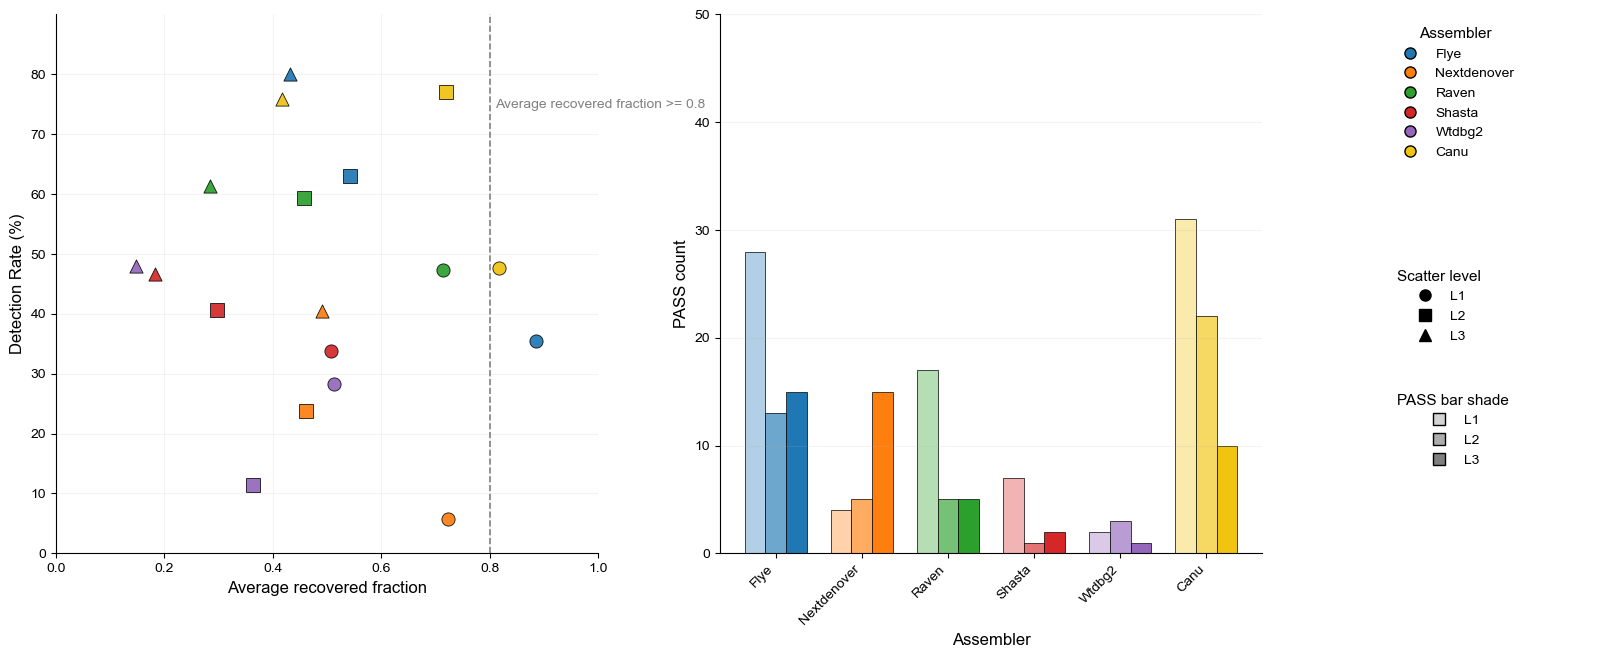

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np

# use Arial font
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# load new summary csv
df = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/local_summary.csv")

# split Tool into assembler + level
df[["tool", "level"]] = df["Tool"].str.rsplit("_", n=1, expand=True)
df["level"] = df["level"].str.lower()
df["level"] = pd.Categorical(df["level"], categories=["l1", "l2", "l3"], ordered=True)

# keep consistent order
df = df.sort_values(["tool", "level"])

# fixed tool order and colors
tool_order = [
    "Flye",
    "Nextdenover",
    "Raven",
    "Shasta",
    "Wtdbg2",
    "Canu",
]

tool_colors = {
    "Flye": "#1f77b4",
    "Nextdenover": "#ff7f0e",
    "Raven": "#2ca02c",
    "Shasta": "#d62728",
    "Wtdbg2": "#9467bd",
    "Canu": "#f1c40f",
}

tools = [t for t in tool_order if t in df["tool"].unique()]
extra_tools = [t for t in df["tool"].unique() if t not in tools]
tools = tools + extra_tools

colors = {
    t: tool_colors.get(t, "#7f7f7f")
    for t in tools
}

marker_map = {"l1": "o", "l2": "s", "l3": "^"}

# add small jitter to reduce overlapping points
rng = np.random.default_rng(42)
df["Accuracy_plot"] = df["Accuracy"] + rng.normal(0, 0.008, size=len(df))
df["Recall_plot"] = df["Recall"] + rng.normal(0, 0.8, size=len(df))

df["Accuracy_plot"] = df["Accuracy_plot"].clip(0, 1)
df["Recall_plot"] = df["Recall_plot"].clip(0, 80)

def lighten_color(color, amount=0.5):
    """
    amount: 0 = original color, 1 = white
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * amount)

level_lighten = {
    "l1": 0.65,
    "l2": 0.35,
    "l3": 0.00,
}

# figure: scatter + pass bar plot + legend
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 0.45], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[0, 2])
ax_leg.axis("off")

# -------------------------
# Average recovered fraction vs Detection rate scatter
# -------------------------
for lv, mk in marker_map.items():
    sub = df[df["level"] == lv]
    ax.scatter(
        sub["Accuracy_plot"], sub["Recall_plot"],
        color="lightgray",
        marker=mk,
        s=95,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.75,
        zorder=1
    )

for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(
            row["Accuracy_plot"], row["Recall_plot"],
            color=colors[tool],
            marker=marker_map[row["level"]],
            s=90,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
            zorder=3
        )

thr = 0.8
ax.axvline(thr, linestyle="--", linewidth=1.2, color="gray", zorder=2)
ax.text(
    thr + 0.01,
    76,
    "Average recovered fraction >= 0.8",
    color="gray",
    fontsize=10,
    va="top"
)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 90)

ax.set_xlabel("Average recovered fraction", fontsize=12)
ax.set_ylabel("Detection Rate (%)", fontsize=12)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 81, 10))

ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------------------------
# PASS grouped bar plot
# -------------------------
x = np.arange(len(tools))
bar_width = 0.24

for i, lv in enumerate(["l1", "l2", "l3"]):
    sub = df[df["level"] == lv].set_index("tool").reindex(tools)

    bar_colors = [
        lighten_color(colors[t], amount=level_lighten[lv])
        for t in tools
    ]

    ax_bar.bar(
        x + (i - 1) * bar_width,
        sub["Pass"],
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.5,
        label=lv.upper()
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(tools, rotation=45, ha="right")
ax_bar.set_ylabel("PASS count", fontsize=12)
ax_bar.set_xlabel("Assembler", fontsize=12)
ax_bar.set_ylim(0, 50)
ax_bar.set_yticks(np.arange(0, 51, 10))

ax_bar.grid(axis="y", alpha=0.15)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# -------------------------
# Legends
# -------------------------
tool_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=tool,
        markerfacecolor=colors[tool],
        markeredgecolor="black",
        markersize=8
    )
    for tool in tools
]

level_handles = [
    Line2D(
        [0], [0],
        marker=marker_map[l],
        color="black",
        linestyle="None",
        label=l.upper(),
        markersize=8
    )
    for l in ["l1", "l2", "l3"]
]

bar_level_handles = [
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label=l.upper(),
        markerfacecolor=lighten_color("gray", amount=level_lighten[l]),
        markeredgecolor="black",
        markersize=8
    )
    for l in ["l1", "l2", "l3"]
]

leg1 = ax_leg.legend(
    handles=tool_handles,
    title="Assembler",
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax_leg.add_artist(leg1)

leg2 = ax_leg.legend(
    handles=level_handles,
    title="Scatter level",
    loc="upper left",
    bbox_to_anchor=(0, 0.55),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax_leg.add_artist(leg2)

ax_leg.legend(
    handles=bar_level_handles,
    title="PASS bar shade",
    loc="upper left",
    bbox_to_anchor=(0, 0.32),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.savefig("Accuracy_Recall_PASS.pdf", bbox_inches="tight")
fig.savefig("Accuracy_Recall_PASS.png", dpi=600, bbox_inches="tight")

plt.show()

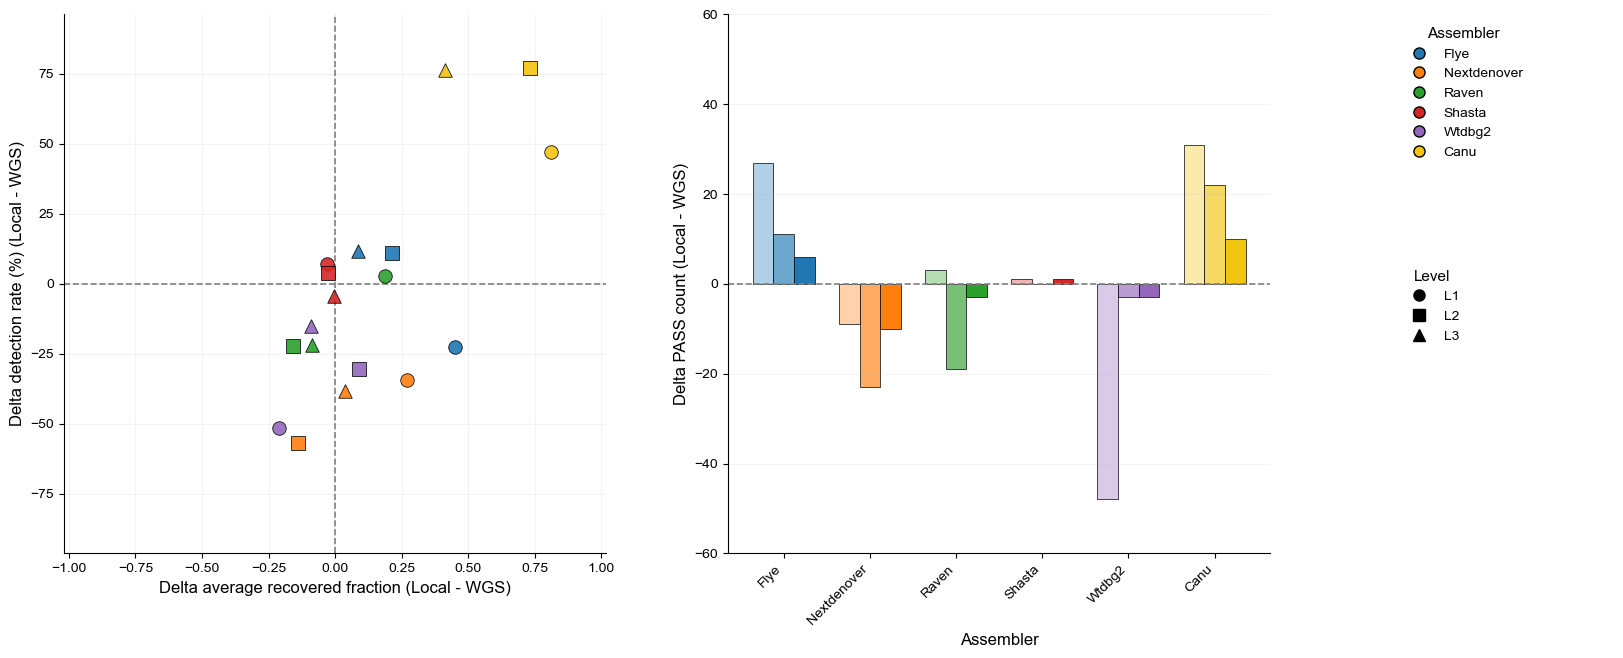

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

local = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/local_summary.csv")
wgs = pd.read_csv("/Users/ppxinyi/Documents/1Review_paper/Evaluate/wgs/wgs_summary.csv")

def prep(df):
    df = df.copy()
    df[["tool", "level"]] = df["Tool"].str.rsplit("_", n=1, expand=True)
    df["level"] = df["level"].str.lower()
    df["level"] = pd.Categorical(df["level"], categories=["l1", "l2", "l3"], ordered=True)
    return df

local = prep(local)
wgs = prep(wgs)

df = local.merge(
    wgs,
    on=["tool", "level"],
    suffixes=("_local", "_wgs")
)

df["Accuracy_delta"] = df["Accuracy_local"] - df["Accuracy_wgs"]
df["Recall_delta"] = df["Recall_local"] - df["Recall_wgs"]
df["Pass_delta"] = df["Pass_local"] - df["Pass_wgs"]

tool_order = [
    "Flye",
    "Nextdenover",
    "Raven",
    "Shasta",
    "Wtdbg2",
    "Canu",
]

tool_colors = {
    "Flye": "#1f77b4",
    "Nextdenover": "#ff7f0e",
    "Raven": "#2ca02c",
    "Shasta": "#d62728",
    "Wtdbg2": "#9467bd",
    "Canu": "#f1c40f",
}

tools = [t for t in tool_order if t in df["tool"].unique()]
extra_tools = [t for t in df["tool"].unique() if t not in tools]
tools = tools + extra_tools

colors = {t: tool_colors.get(t, "#7f7f7f") for t in tools}
marker_map = {"l1": "o", "l2": "s", "l3": "^"}

rng = np.random.default_rng(42)
df["Accuracy_delta_plot"] = df["Accuracy_delta"] + rng.normal(0, 0.004, size=len(df))
df["Recall_delta_plot"] = df["Recall_delta"] + rng.normal(0, 0.5, size=len(df))

def lighten_color(color, amount=0.5):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * amount)

level_lighten = {
    "l1": 0.65,
    "l2": 0.35,
    "l3": 0.00,
}

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 0.45], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[0, 2])
ax_leg.axis("off")

# -------------------------
# Delta scatter: Local - WGS
# -------------------------
for tool, sub in df.groupby("tool"):
    for _, row in sub.iterrows():
        ax.scatter(
            row["Accuracy_delta_plot"],
            row["Recall_delta_plot"],
            color=colors[tool],
            marker=marker_map[str(row["level"])],
            s=95,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
            zorder=3
        )

ax.axvline(0, linestyle="--", linewidth=1.2, color="gray")
ax.axhline(0, linestyle="--", linewidth=1.2, color="gray")

ax.set_xlabel("Delta average recovered fraction (Local - WGS)", fontsize=12)
ax.set_ylabel("Delta detection rate (%) (Local - WGS)", fontsize=12)

xmax = max(abs(df["Accuracy_delta"].min()), abs(df["Accuracy_delta"].max()), 0.05)
ymax = max(abs(df["Recall_delta"].min()), abs(df["Recall_delta"].max()), 5)

ax.set_xlim(-xmax * 1.25, xmax * 1.25)
ax.set_ylim(-ymax * 1.25, ymax * 1.25)

ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------------------------
# PASS delta grouped bar plot
# -------------------------
x = np.arange(len(tools))
bar_width = 0.24

for i, lv in enumerate(["l1", "l2", "l3"]):
    sub = df[df["level"].astype(str) == lv].set_index("tool").reindex(tools)

    bar_colors = [
        lighten_color(colors[t], amount=level_lighten[lv])
        for t in tools
    ]

    ax_bar.bar(
        x + (i - 1) * bar_width,
        sub["Pass_delta"],
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.5,
        label=lv.upper()
    )

ax_bar.axhline(0, linestyle="--", linewidth=1.2, color="gray")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(tools, rotation=45, ha="right")
ax_bar.set_ylabel("Delta PASS count (Local - WGS)", fontsize=12)
ax_bar.set_xlabel("Assembler", fontsize=12)

pass_max = max(abs(df["Pass_delta"].min()), abs(df["Pass_delta"].max()), 1)
ax_bar.set_ylim(-pass_max * 1.25, pass_max * 1.25)

ax_bar.grid(axis="y", alpha=0.15)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# -------------------------
# Legends
# -------------------------
tool_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=tool,
        markerfacecolor=colors[tool],
        markeredgecolor="black",
        markersize=8
    )
    for tool in tools
]

level_handles = [
    Line2D(
        [0], [0],
        marker=marker_map[l],
        color="black",
        linestyle="None",
        label=l.upper(),
        markersize=8
    )
    for l in ["l1", "l2", "l3"]
]

leg1 = ax_leg.legend(
    handles=tool_handles,
    title="Assembler",
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax_leg.add_artist(leg1)

ax_leg.legend(
    handles=level_handles,
    title="Level",
    loc="upper left",
    bbox_to_anchor=(0, 0.55),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# fig.savefig("Local_vs_WGS_delta.pdf", bbox_inches="tight")
# fig.savefig("Local_vs_WGS_delta.png", dpi=600, bbox_inches="tight")

plt.show()

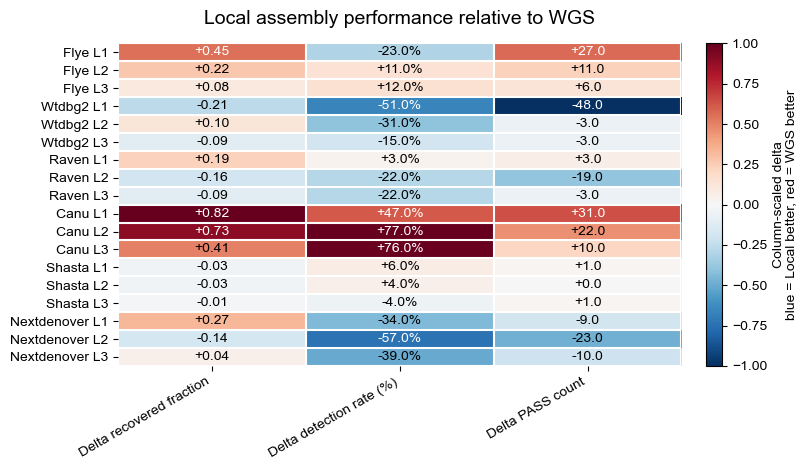

In [4]:
# -------------------------
# Delta summary heatmap
# -------------------------
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# If Accuracy is fraction, keep as fraction delta.
# If Recall is already percent, keep as percent delta.
heat = (
    df.groupby("tool", observed=True)
      .agg(
          **{
              "Delta recovered fraction": ("Accuracy_delta", "mean"),
              "Delta detection rate (%)": ("Recall_delta", "mean"),
              "Delta PASS count": ("Pass_delta", "mean"),
          }
      )
      .reindex(tools)
)

# Optional: remove tools not present
heat = (
    df.assign(tool_level=df["tool"] + " " + df["level"].astype(str).str.upper())
      .set_index("tool_level")
      .loc[:, ["Accuracy_delta", "Recall_delta", "Pass_delta"]]
      .rename(columns={
          "Accuracy_delta": "Delta recovered fraction",
          "Recall_delta": "Delta detection rate (%)",
          "Pass_delta": "Delta PASS count",
      })
)

# Scale columns independently for color only, so PASS does not dominate.
heat_scaled = heat.copy()
for col in heat_scaled.columns:
    vmax = np.nanmax(np.abs(heat_scaled[col].values))
    if vmax == 0 or np.isnan(vmax):
        heat_scaled[col] = 0
    else:
        heat_scaled[col] = heat_scaled[col] / vmax

fig, ax = plt.subplots(figsize=(8.2, 4.8))

cmap = plt.get_cmap("RdBu_r")
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(heat_scaled.values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels(heat.index)

ax.set_title("Local assembly performance relative to WGS", fontsize=14, pad=14)

# Draw grid
ax.set_xticks(np.arange(-0.5, heat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heat.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate cells with original values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.isna(val):
            text = ""
        elif heat.columns[j] == "Delta recovered fraction":
            text = f"{val:+.2f}"
        elif heat.columns[j] == "Delta detection rate (%)":
            text = f"{val:+.1f}%"
        else:
            text = f"{val:+.1f}"

        color = "white" if abs(heat_scaled.iloc[i, j]) > 0.55 else "black"
        ax.text(j, i, text, ha="center", va="center", fontsize=10, color=color)

# Colorbar explains direction, not raw units
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Column-scaled delta\nblue = WGS better, red = Local better", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

fig.tight_layout()
# fig.savefig("Local_vs_WGS_delta_heatmap.pdf", bbox_inches="tight")
# fig.savefig("Local_vs_WGS_delta_heatmap.png", dpi=600, bbox_inches="tight")

plt.show()

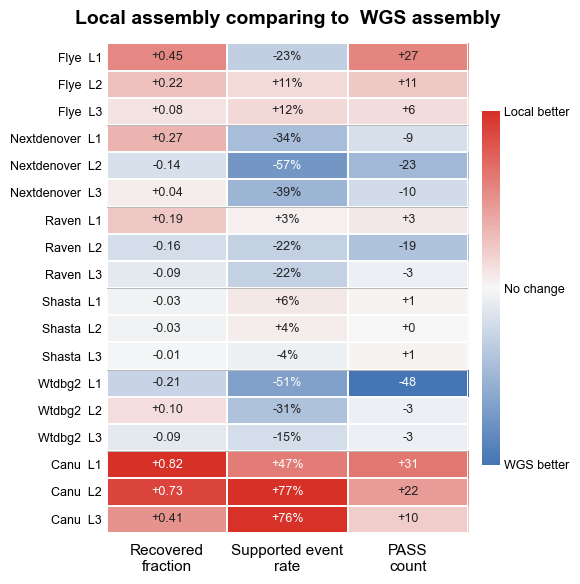

In [8]:
# -------------------------
# Polished delta summary heatmap
# -------------------------
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Keep each assembler-level as one row
heat = (
    df.assign(
        level_str=df["level"].astype(str).str.upper(),
        tool_level=df["tool"] + "  " + df["level"].astype(str).str.upper()
    )
    .sort_values(["tool", "level"])
    .set_index("tool_level")
    .loc[:, ["Accuracy_delta", "Recall_delta", "Pass_delta"]]
    .rename(columns={
        "Accuracy_delta": "Recovered\nfraction",
        "Recall_delta": "Supported event\nrate",
        "Pass_delta": "PASS\ncount",
    })
)

# Reorder rows by your preferred assembler order
row_order = []
for t in tools:
    for lv in ["L1", "L2", "L3"]:
        name = f"{t}  {lv}"
        if name in heat.index:
            row_order.append(name)
heat = heat.loc[row_order]

# Column-wise scaling for colors only
heat_scaled = heat.copy()
for col in heat_scaled.columns:
    vmax = np.nanmax(np.abs(heat_scaled[col].values))
    heat_scaled[col] = 0 if vmax == 0 or np.isnan(vmax) else heat_scaled[col] / vmax

# Softer diverging palette:
# blue = WGS better / negative, white = no change, red = Local better / positive
cmap = mcolors.LinearSegmentedColormap.from_list(
    "soft_delta",
    ["#4575b4", "#f7f7f7", "#d73027"],
    N=256
)
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

n_rows, n_cols = heat.shape
fig_h = max(4.2, n_rows * 0.33)
fig, ax = plt.subplots(figsize=(5.9, fig_h))

im = ax.imshow(heat_scaled.values, cmap=cmap, norm=norm, aspect="auto")

# Axis labels
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(heat.columns, fontsize=11)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(heat.index, fontsize=9)

ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", length=0)

# White cell grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)

# Slight separators between assemblers
for k in range(3, n_rows, 3):
    ax.axhline(k - 0.5, color="#333333", linewidth=0.7, alpha=0.35)

# Cell annotations
for i in range(n_rows):
    for j in range(n_cols):
        val = heat.iloc[i, j]
        scaled = heat_scaled.iloc[i, j]

        if pd.isna(val):
            text = ""
        elif heat.columns[j] == "Recovered\nfraction":
            text = f"{val:+.2f}"
        elif heat.columns[j] == "Supported event\nrate":
            text = f"{val:+.0f}%"
        else:
            text = f"{val:+.0f}"

        txt_color = "white" if abs(scaled) > 0.58 else "#222222"
        ax.text(
            j, i, text,
            ha="center", va="center",
            fontsize=9,
            color=txt_color
        )

# Title
ax.set_title(
    "Local assembly comparing to  WGS assembly",
    fontsize=14,
    fontweight="bold",
    pad=14
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.035)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["WGS better", "No change", "Local better"])
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_visible(False)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig("Local_vs_WGS_delta_heatmap_polished.pdf", bbox_inches="tight")
fig.savefig("Local_vs_WGS_delta_heatmap_polished.png", dpi=600, bbox_inches="tight")

plt.show()